In [2]:
import numpy as np
import matplotlib.pyplot as plt



In [17]:
def simulate_gbm_paths(S0=100, mu=0.0, sigma=0.2, T=1.0, n_steps=252, n_paths=5000, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    dlogSt = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z #dlogSt
    integral_dlogSt = np.cumsum(dlogSt, axis=1) # integral dlogSt
    S = S0 * np.exp(np.column_stack([np.zeros(n_paths), integral_dlogSt])) 
    # add initial time t0 =0 for each path, S start with S0
    return S

# shape of S : (n_paths, n_steps + 1)

def realized_log_variance(S): # benchmark
    logSt_diff = np.diff(np.log(S), axis=1) # diff of logSt
    return np.sum(logSt_diff**2, axis=1)

def variance_replication_discrete(S):
    return_St = np.diff(S, axis=1) / S[:, :-1] # (S_t - S_t-1) / S_t-1 , S[:, :-1]: all paths, and all columns except the last one
    
    const_dollar_gain = np.sum(return_St, axis=1)
    log_contract =  np.log(S[:, -1] / S[:, 0]) #logS_T/logS_0
    return 2.0 * const_dollar_gain -2.0 * log_contract 
# realized variance discrete form, variance swap replication identity

def delta_hedged_log_contract_pnl(S): #portfolio construction
    g =  np.log(S / S[:, [0]]) # log contract, use log(S) is the same
    dg = np.diff(g, axis=1)

    dS = np.diff(S, axis=1)
    hedge_gain = (1.0 / S[:, :-1]) * dS #constant-dollar hedge gain

    pnl_increment = -2.0 * dg + 2.0 * hedge_gain #d_pi 
    cumulative_pnl = np.sum(pnl_increment, axis=1)
    return cumulative_pnl






In [19]:

S = simulate_gbm_paths(sigma=0.2, n_steps=252, n_paths=5000)

rv_log = realized_log_variance(S) #benchmark
rv_rep = variance_replication_discrete(S) #realized variance discrete form

log_hedged_pnl = delta_hedged_log_contract_pnl(S)

In [21]:
print("Mean log realized variance:", rv_log.mean())
print("Mean replicated variance:", rv_rep.mean())
print("Theoretical integrated variance:", 0.2**2 * 1.0)
print("Mean replication error:", np.mean(rv_rep - rv_log))
print("RMSE replication error:", np.sqrt(np.mean((rv_rep - rv_log)**2)))

print("Mean delta-hedged log P&L:", log_hedged_pnl.mean())
print("Mean realized log variance:", rv_log.mean())
print("Mean difference:", np.mean(log_hedged_pnl - rv_log))
print("RMSE error:", np.sqrt(np.mean((log_hedged_pnl - rv_log)**2)))

Mean log realized variance: 0.03999687632214842
Mean replicated variance: 0.039995777940029696
Theoretical integrated variance: 0.04000000000000001
Mean replication error: -1.0983821187242024e-06
RMSE replication error: 4.020259853403873e-05
Mean delta-hedged log P&L: 0.039995777940029696
Mean realized log variance: 0.03999687632214842
Mean difference: -1.0983821187237465e-06
RMSE error: 4.0202598534040756e-05


In [42]:
def simulate_gbm(S0=100, mu=0.0, sigma=0.25, T=1.0, n_steps=252, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal(n_steps) #shape of Z: (n_steps,)

    dlogSt  = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z #dlogSt
    integral_dlogSt = np.r_[0.0, np.cumsum(dlogSt)] #start with 0, and then append the cumulative sum of dlogSt, shape of log_S: (n_steps + 1,)
    S = S0 * np.exp(integral_dlogSt) # shape of S: (n_steps + 1,)

    return S, dt

S, dt = simulate_gbm(sigma=0.25, n_steps=252)

S_prev = S[:-1]
S_next = S[1:]

return_St = (S_next - S_prev) / S_prev # (S_t - S_t-1) / S_t-1 
log_ret = np.log(S_next / S_prev)

# Benchmark realized variance increment
rv_log_step = log_ret**2

# Portfolio replication increment:
# long negative-log contract + long 2/S stock hedge
rep_step = 2 * (return_St - log_ret) # could reuse the log contract and constant-dollar hedge gain from previous function

# Add fixed leg to create variance swap P&L
sigma_imp = 0.20
fixed_var_step = sigma_imp**2 * dt
varswap_pnl_step = rep_step - fixed_var_step

# Cumulative values
cum_rv_log = np.cumsum(rv_log_step)
cum_rep = np.cumsum(rep_step)
cum_varswap_pnl = np.cumsum(varswap_pnl_step)

time = np.arange(1, len(S)) * dt

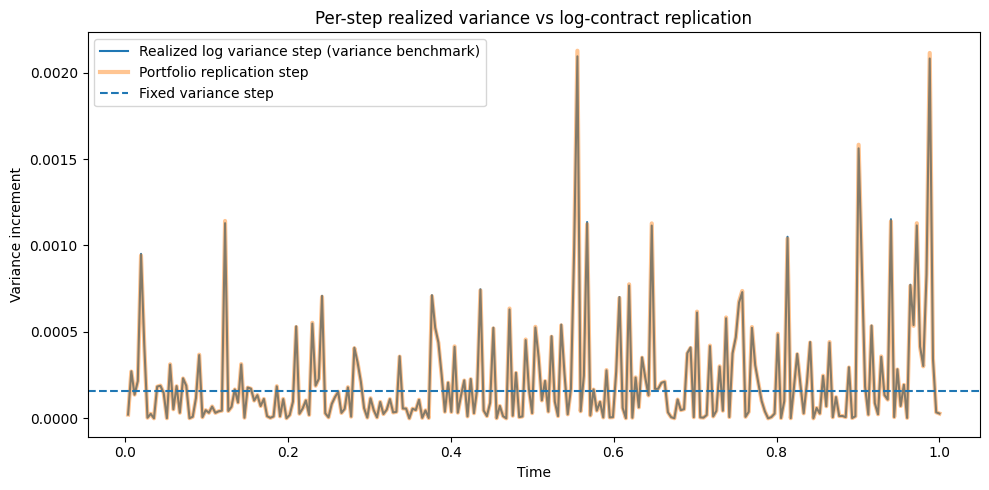

In [52]:
# Plot 1: per-step increments
plt.figure(figsize=(10, 5))
plt.plot(time, rv_log_step, label="Realized log variance step (variance benchmark)") 
# squared log return
plt.plot(time, rep_step, label="Portfolio replication step", linewidth=3, alpha=0.45) 
# discrete log-contract portfolio increment, short log-contract+constant dollar hedge
plt.axhline(fixed_var_step, linestyle="--", label="Fixed variance step")
plt.title("Per-step realized variance vs log-contract replication")
plt.xlabel("Time")
plt.ylabel("Variance increment")
plt.legend()
plt.tight_layout()
plt.show()


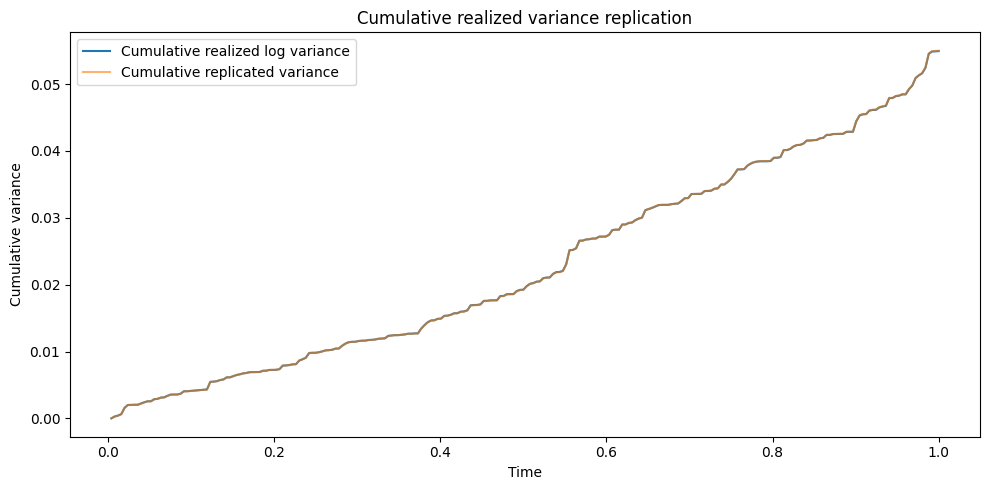

In [42]:

# Plot 2: cumulative realized variance
plt.figure(figsize=(10, 5))
plt.plot(time, cum_rv_log, label="Cumulative realized log variance")
plt.plot(time, cum_rep, label="Cumulative replicated variance", linewidth=3,alpha=0.6)
plt.title("Cumulative realized variance replication")
plt.xlabel("Time")
plt.ylabel("Cumulative variance")
plt.legend()
plt.tight_layout()
plt.show()


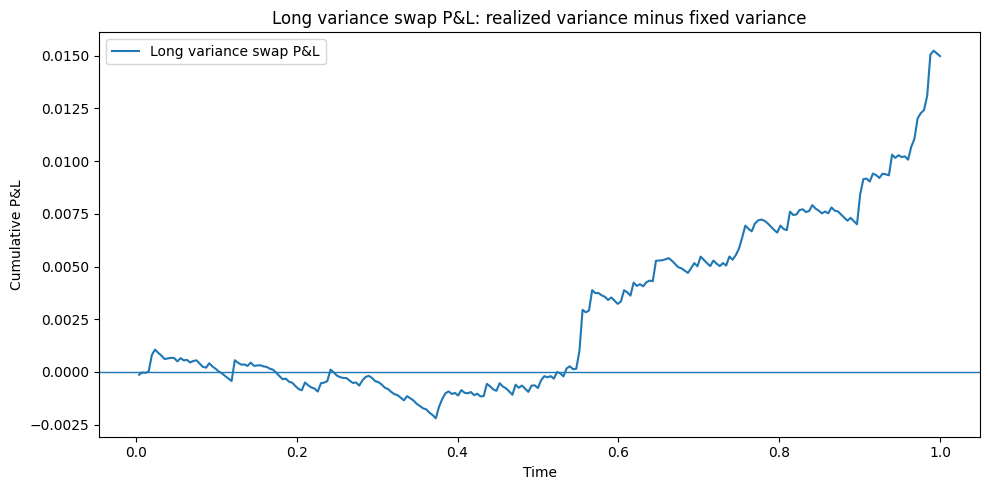

In [31]:
# Plot 3: variance swap P&L
plt.figure(figsize=(10, 5))
plt.plot(time, cum_varswap_pnl, label="Long variance swap P&L")
plt.axhline(0, linewidth=1)
plt.title("Long variance swap P&L: realized variance minus fixed variance")
plt.xlabel("Time")
plt.ylabel("Cumulative P&L")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:

print("Final realized log variance:", cum_rv_log[-1])
print("Final replicated variance:", cum_rep[-1])
print("Replication error:", cum_rep[-1] - cum_rv_log[-1])
print("Final variance swap P&L:", cum_varswap_pnl[-1])

Final realized log variance: 0.05492593282494077
Final replicated variance: 0.054983911888510005
Replication error: 5.797906356923288e-05
Final variance swap P&L: 0.014983911888510023


In [24]:
def simulate_gbm(S0=100, mu=0.0, sigma=0.25, T=1.0, n_steps=252, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal(n_steps) #shape of Z: (n_steps,)

    dlogSt  = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z #dlogSt
    integral_dlogSt = np.r_[0.0, np.cumsum(dlogSt)] #start with 0, and then append the cumulative sum of dlogSt, shape of log_S: (n_steps + 1,)
    S = S0 * np.exp(integral_dlogSt) # shape of S: (n_steps + 1,)

    return S, dt

S, dt = simulate_gbm(sigma=0.25, n_steps=252)


S_prev = S[:-1]
S_next = S[1:]

dS = S_next - S_prev
simple_ret = dS / S_prev
log_ret = np.log(S_next / S_prev)

# --------------------------------------------------
# Portfolio construction written explicitly
# --------------------------------------------------

# Short log payoff: g(S) =  - log(S / S0)
g = - np.log(S / S[0])
log_contract_increment = np.diff(g)

# Long constant-dollar stock hedge
hedge_units = 1 / S_prev
hedge_gain = hedge_units * dS

# Total discrete portfolio gain
portfolio_rep_step =  2 * log_contract_increment + 2 * hedge_gain

# --------------------------------------------------
# Algebraically compressed version
# --------------------------------------------------

rep_step_direct = 2.0 * (simple_ret - log_ret)

# assert np.allclose(portfolio_rep_step, rep_step_direct)

# Realized log-return variance benchmark
rv_log_step = log_ret**2

# Finite-monitoring difference
replication_gap_step = portfolio_rep_step - rv_log_step

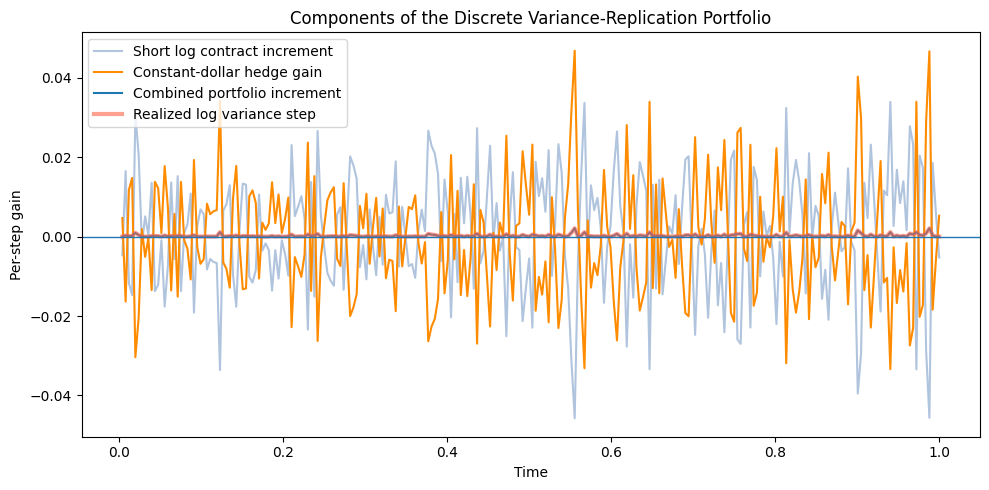

In [54]:
time = np.arange(1, len(S)) * dt

plt.figure(figsize=(10, 5))

plt.plot(
    time,
    log_contract_increment,
    label="Short log contract increment",
    color = 'lightsteelblue',
)

plt.plot(
    time,
    hedge_gain,
    label="Constant-dollar hedge gain",
    color = 'darkorange'
)

plt.plot(
    time,
    portfolio_rep_step,
    label="Combined portfolio increment",
    linewidth=1.5
)

plt.plot(time, 
         rv_log_step, 
         label="Realized log variance step",
         linewidth=3,
         alpha =0.6,
         color = 'tomato'
        )

plt.axhline(0, linewidth=1)

plt.title("Components of the Discrete Variance-Replication Portfolio")
plt.xlabel("Time")
plt.ylabel("Per-step gain")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# the log contract increment and hedge gains are approximately mirror images.
# first-order gains cancel almost exactly.
# higher-order terms remain.the equality is not exact at daily monitoring frequency.
# the residual asymmetry is the realized-variance exposure.


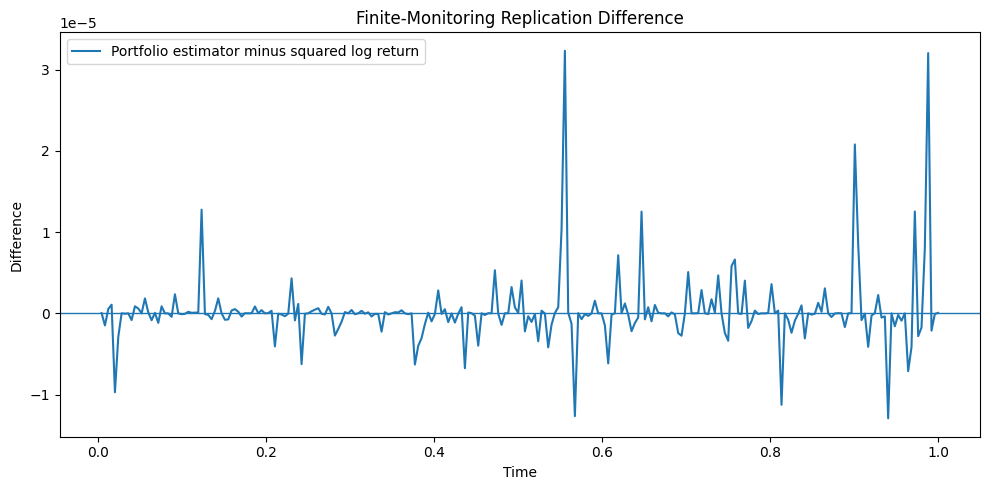

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    time,
    replication_gap_step,
    label="Portfolio estimator minus squared log return"
)

plt.axhline(0, linewidth=1)

plt.title("Finite-Monitoring Replication Difference")
plt.xlabel("Time")
plt.ylabel("Difference")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print(
    "Mean step difference:",
    np.mean(replication_gap_step)
)

print(
    "Step RMSE:",
    np.sqrt(np.mean(replication_gap_step**2))
)

print(
    "Final cumulative difference:",
    np.sum(replication_gap_step)
)

Mean step difference: 2.300756490793509e-07
Step RMSE: 4.265700420910886e-06
Final cumulative difference: 5.797906356799642e-05
